In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/air quality dataset.csv')
df.head(5)

,Country,City,AQI_Value,AQI_Category,CO AQI_Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [ ]:
print(df.isnull().sum())

Country               427
City                    1
AQI_Value               0
AQI_Category            0
CO AQI_Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64


In [ ]:
df.shape

(23463, 12)

In [ ]:
print(f"Shape of the Dataset: {df.shape}")

Shape of the Dataset: (23463, 12)


In [ ]:
print(df.columns)

Index(['Country', 'City', 'AQI_Value', 'AQI_Category', 'CO AQI_Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')


In [ ]:
data=df.fillna(df.mode().iloc[0])
data.head()

,Country,City,AQI_Value,AQI_Category,CO AQI_Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [ ]:
Q1 = df['AQI_Value'].quantile(0.25)
Q3 = df['AQI_Value'].quantile(0.75)
IQR = Q3 - Q1

In [ ]:
LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR

In [ ]:
outliers = df[(df['AQI_Value'] < LB) | (df['AQI_Value'] > UB)]

In [ ]:
total_outliers_detected = outliers.shape[0]
print("Total No.of Outliers Detected:",total_outliers_detected)

Total No.of Outliers Detected: 2935


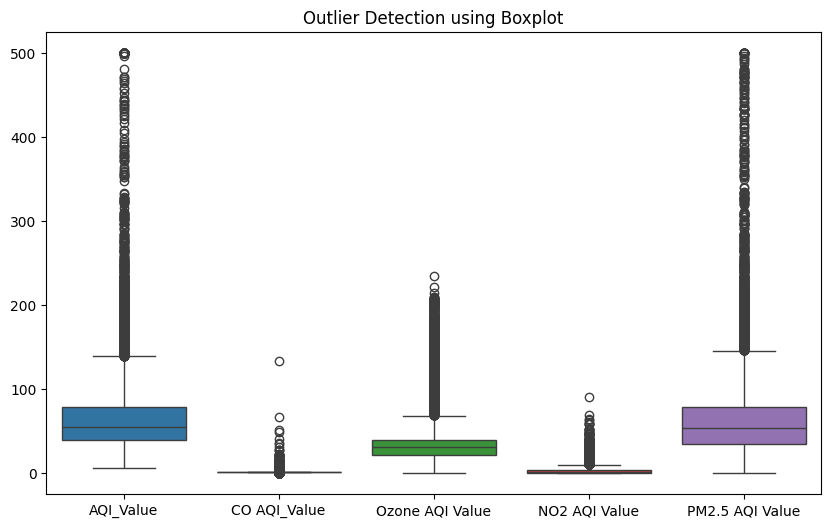

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title('Outlier Detection using Boxplot')
plt.show()

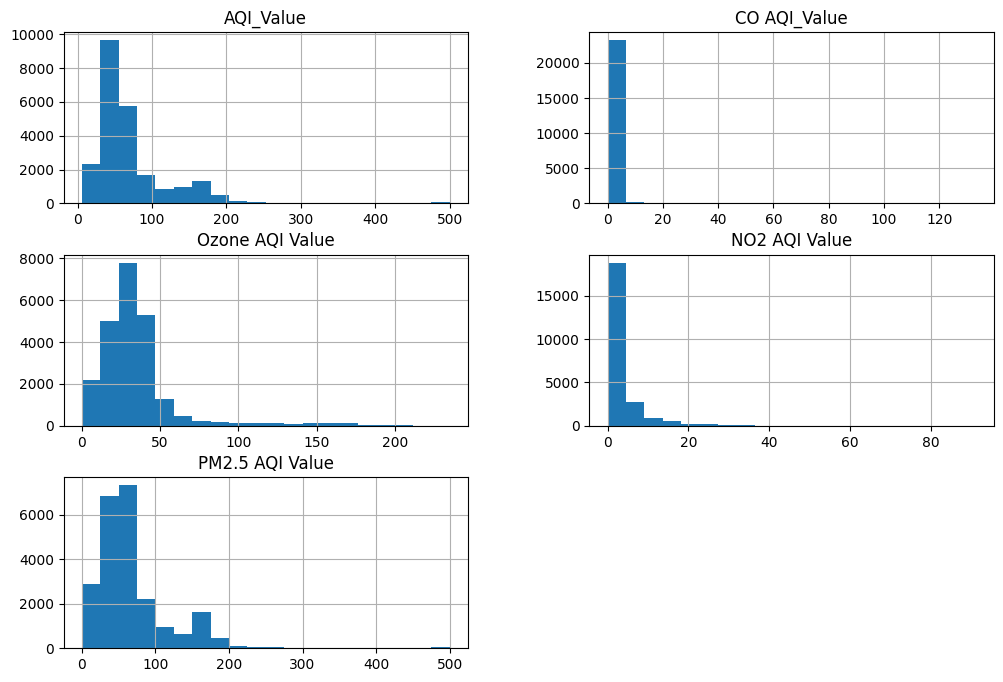

In [ ]:
df.hist(figsize=(12, 8), bins=20)
plt.show()

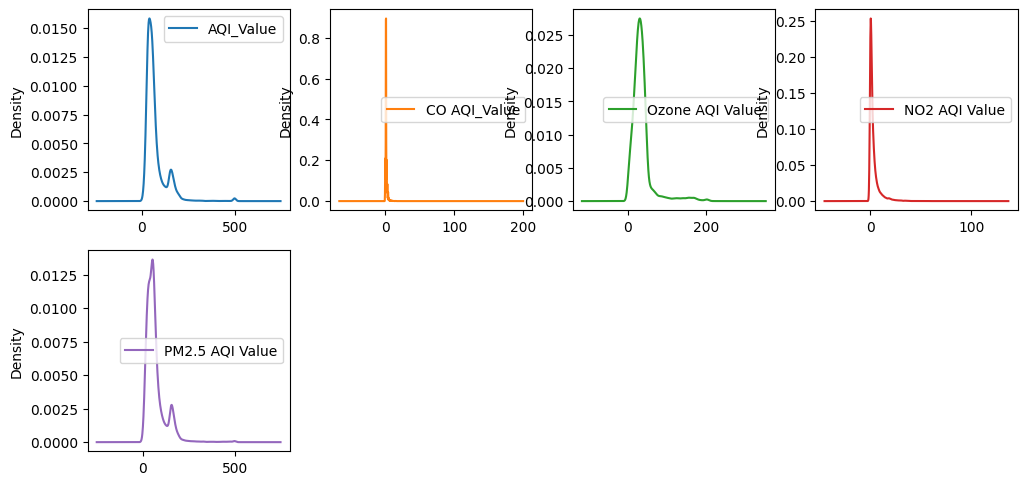

In [ ]:
df.select_dtypes(include=np.number).plot(kind='density', subplots=True, layout=(4, 4), figsize=(12, 12), sharex=False)
plt.show()

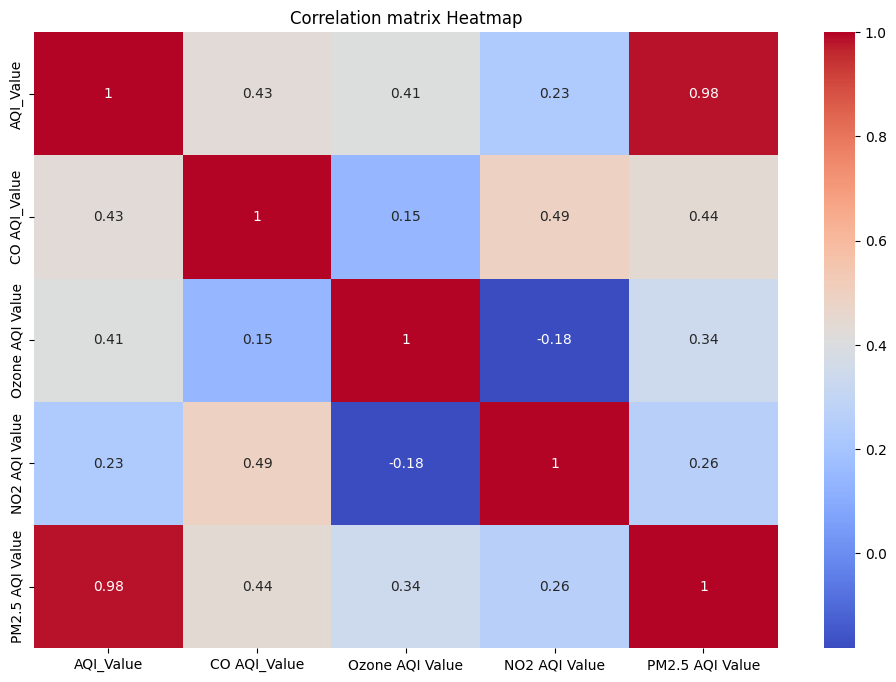

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title('Correlation matrix Heatmap')
plt.show()

In [ ]:
def correlation(dataset,threshold):
  col_corr=set()
  corr_matrix=dataset.select_dtypes(include=np.number).corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if (corr_matrix.iloc[i,j])>threshold:
        colname=corr_matrix.columns[i]
        col_corr.add(colname)
  return col_corr

In [ ]:
X_train=df
X_test=df
corr_features=correlation(X_train,0.1)
len(set(corr_features))

4

In [ ]:
corr_features

{'CO AQI_Value', 'NO2 AQI Value', 'Ozone AQI Value', 'PM2.5 AQI Value'}

In [ ]:
X_train.drop(corr_features,axis=1)
X_test.drop(corr_features,axis=1)

,Country,City,AQI_Value,AQI_Category,CO AQI Category,Ozone AQI Category,NO2 AQI Category,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,Good,Good,Good,Moderate
1,Brazil,Presidente Dutra,41,Good,Good,Good,Good,Good
2,Italy,Priolo Gargallo,66,Moderate,Good,Good,Good,Moderate
3,Poland,Przasnysz,34,Good,Good,Good,Good,Good
4,France,Punaauia,22,Good,Good,Good,Good,Good
...,...,...,...,...,...,...,...,...
23458,India,Gursahaiganj,184,Unhealthy,Good,Unhealthy,Good,Unhealthy
23459,France,Sceaux,50,Good,Good,Good,Good,Good
23460,India,Mormugao,50,Good,Good,Good,Good,Good
23461,United States of America,Westerville,71,Moderate,Good,Good,Good,Moderate


In [ ]:
X = df.drop('AQI_Category', axis=1)
y = df['AQI_Category']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical_features=['Country','City','AQI_Category','CO AQI Category','Ozone AQI Category','NO2 AQI Category','PM2.5 AQI Category']
one_hot=OneHotEncoder()
transformer=ColumnTransformer([('one_hot',one_hot,categorical_features)],remainder='passthrough')
transformed_X=transformer.fit_transform(df)
transformed_X
transformed_y=transformer.fit_transform(df)
transformed_y

<23463x23666 sparse matrix of type '<class 'numpy.float64'>'
	with 270100 stored elements in Compressed Sparse Row format>

In [ ]:
new_var = pd.DataFrame(transformed_X)
new_var

,0
0,"(0, 130)\t1.0\n (0, 16701)\t1.0\n (0, 2364..."
1,"(0, 22)\t1.0\n (0, 16722)\t1.0\n (0, 23639..."
2,"(0, 75)\t1.0\n (0, 16758)\t1.0\n (0, 23641..."
3,"(0, 123)\t1.0\n (0, 16794)\t1.0\n (0, 2363..."
4,"(0, 54)\t1.0\n (0, 16875)\t1.0\n (0, 23639..."
...,...
23458,"(0, 69)\t1.0\n (0, 7697)\t1.0\n (0, 23642)..."
23459,"(0, 54)\t1.0\n (0, 18807)\t1.0\n (0, 23639..."
23460,"(0, 69)\t1.0\n (0, 13678)\t1.0\n (0, 23639..."
23461,"(0, 166)\t1.0\n (0, 22772)\t1.0\n (0, 2364..."


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier

label_encoder = LabelEncoder()
X = df.drop('PM2.5 AQI Category', axis=1)
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    X[col] = label_encoder.fit_transform(X[col])
y = label_encoder.fit_transform(df['PM2.5 AQI Category'])

model = DecisionTreeClassifier()
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)
selected_features = rfe.get_support(indices=True)

print("RFE :", rfe.support_)
print(rfe.ranking_)
print(selected_features)

RFE : [False False False False False False  True  True  True  True  True]
[7 6 5 4 3 2 1 1 1 1 1]
[ 6  7  8  9 10]


In [ ]:
print(selected_features.shape)
selected_features_columnames=X.columns[selected_features]
print(selected_features_columnames)

(5,)
Index(['Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value',
       'NO2 AQI Category', 'PM2.5 AQI Value'],
      dtype='object')


In [ ]:
Rankings = rfe.ranking_
Features = X.columns

In [ ]:
from prettytable import PrettyTable
table = PrettyTable()
table.field_names = ['Feature', 'Ranking']
for feature, ranking in zip(Features, Rankings):
    table.add_row([feature, ranking])
print(table)

+--------------------+---------+
|      Feature       | Ranking |
+--------------------+---------+
|      Country       |    7    |
|        City        |    6    |
|     AQI_Value      |    5    |
|    AQI_Category    |    4    |
|    CO AQI_Value    |    3    |
|  CO AQI Category   |    2    |
|  Ozone AQI Value   |    1    |
| Ozone AQI Category |    1    |
|   NO2 AQI Value    |    1    |
|  NO2 AQI Category  |    1    |
|  PM2.5 AQI Value   |    1    |
+--------------------+---------+


In [ ]:
from prettytable import PrettyTable
table = PrettyTable()
table.field_names = ['Feature', 'Ranking']
 for feature, ranking in zip(selected_features, Rankings):
    table.add_row([feature, ranking])
print(table)

+---------+---------+
| Feature | Ranking |
+---------+---------+
|    6    |    7    |
|    7    |    6    |
|    8    |    5    |
|    9    |    4    |
|    10   |    3    |
+---------+---------+


In [ ]:
import pandas as pd
ranking_df = pd.DataFrame({
    'Feature': ['Country', 'City', 'AQI_Category', 'CO_AQI_Value', 'CO_AQI_Category',
       'Ozone_AQI_Value', 'Ozone_AQI_Category', 'NO2_AQI_Value',
       'NO2_AQI_Category', 'PM2.5_AQI_Value', 'PM2.5_AQI_Category'],
    'Ranking': Rankings
})
ranking_df = ranking_df[ranking_df['Feature'].isin(selected_features_columnames)]
feature_ranking_df = ranking_df.sort_values(by='Ranking')
print(ranking_df)
new_dataset = df[selected_features_columnames]
print(new_dataset)
feature_ranking_df.to_csv('feature_rankings.csv', index=False)
new_dataset.to_csv('selected_features_dataset.csv', index=False)

Empty DataFrame
Columns: [Feature, Ranking]
Index: []
       Ozone AQI Value Ozone AQI Category  NO2 AQI Value NO2 AQI Category  \
0                   36               Good              0             Good   
1                    5               Good              1             Good   
2                   39               Good              2             Good   
3                   34               Good              0             Good   
4                   22               Good              0             Good   
...                ...                ...            ...              ...   
23458              154          Unhealthy              2             Good   
23459               20               Good              5             Good   
23460               22               Good              1             Good   
23461               44               Good              2             Good   
23462               38               Good              0             Good   

       PM2.5 AQI Valu

In [ ]:
new_dataset.head(10)

,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value
0,36,Good,0,Good,51
1,5,Good,1,Good,41
2,39,Good,2,Good,66
3,34,Good,0,Good,20
4,22,Good,0,Good,6
5,14,Good,11,Good,54
6,35,Good,3,Good,62
7,29,Good,7,Good,64
8,41,Good,1,Good,54
9,89,Moderate,9,Good,142


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)
print(f'SVM Accuracy: {svm_acc}')

SVM Accuracy: 0.9942467504794374


In [ ]:
print('SVM Confusion Matrix:\n {confusion_matrix(y_test, svm_pred)}')

SVM Confusion Matrix:
 {confusion_matrix(y_test, svm_pred)}


In [ ]:
print(f'SVM Classification Report:\n {classification_report(y_test, svm_pred)}')


SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2057
           1       1.00      0.97      0.99        36
           2       1.00      1.00      1.00      1817
           3       0.97      1.00      0.98       403
           4       0.99      0.96      0.98       328
           5       0.94      0.98      0.96        52

    accuracy                           0.99      4693
   macro avg       0.98      0.98      0.98      4693
weighted avg       0.99      0.99      0.99      4693



In [ ]:
ffnn_model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=100)
ffnn_model.fit(X_train_scaled, y_train)
ffnn_pred = ffnn_model.predict(X_test_scaled)
ffnn_acc = accuracy_score(y_test, ffnn_pred)
print(f'FFNN Accuracy: {ffnn_acc}')

FFNN Accuracy: 0.995099083741743


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
print(f'FFNN Confusion Matrix:\n {confusion_matrix(y_test, ffnn_pred)}')

FFNN Confusion Matrix:
 [[2052    0    5    0    0    0]
 [   0   36    0    0    0    0]
 [   1    0 1816    0    0    0]
 [   1    0    0  399    3    0]
 [   0    0    1    5  322    0]
 [   0    6    0    1    0   45]]


In [ ]:
print(f'FFNN Classification Report:\n {classification_report(y_test, ffnn_pred)}')

FFNN Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2057
           1       0.86      1.00      0.92        36
           2       1.00      1.00      1.00      1817
           3       0.99      0.99      0.99       403
           4       0.99      0.98      0.99       328
           5       1.00      0.87      0.93        52

    accuracy                           1.00      4693
   macro avg       0.97      0.97      0.97      4693
weighted avg       1.00      1.00      1.00      4693



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
gbc_model=GradientBoostingClassifier(n_estimators=5,learning_rate=0.5,max_depth=1,random_state=5,loss="log_loss")
gbc_model.fit(X_train_scaled,y_train_encoded)
GBC_pred=gbc_model.predict(X_test_scaled)
GBC_acc=accuracy_score(y_test_encoded,GBC_pred)
print(f'GBC Accuracy:{GBC_acc}')

GBC Accuracy:0.9923290006392499


In [ ]:
print(f'GBC Confusion Matrix:\n {confusion_matrix(y_test_encoded, GBC_pred)}')

GBC Confusion Matrix:
 [[2057    0    0    0    0    0]
 [   0    0    0    0    0   36]
 [   0    0 1817    0    0    0]
 [   0    0    0  403    0    0]
 [   0    0    0    0  328    0]
 [   0    0    0    0    0   52]]


In [ ]:
print(f'Gradient Boosting Classification Report:\n {classification_report(y_test_encoded, GBC_pred)}')

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2057
           1       0.00      0.00      0.00        36
           2       1.00      1.00      1.00      1817
           3       1.00      1.00      1.00       403
           4       1.00      1.00      1.00       328
           5       0.59      1.00      0.74        52

    accuracy                           0.99      4693
   macro avg       0.77      0.83      0.79      4693
weighted avg       0.99      0.99      0.99      4693



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import VotingClassifier
ensemble_model = VotingClassifier(estimators=[
    ('svm', svm_model),
    ('ffnn', ffnn_model),
    ('GBC', gbc_model)], voting='hard', weights=[1, 0.5, 2])
ensemble_model.fit(X_train_scaled, y_train)
ensemble_pred = ensemble_model.predict(X_test_scaled)
ensemble_acc = accuracy_score(y_test, ensemble_pred)
print(f'Ensemble Voting Classifier Accuracy: {ensemble_acc}')
print(f'Ensemble Confusion Matrix:\n {confusion_matrix(y_test, ensemble_pred)}')
print(f'Ensemble Classification Report:\n {classification_report(y_test, ensemble_pred)}')

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Ensemble Voting Classifier Accuracy: 0.9923290006392499
Ensemble Confusion Matrix:
 [[2057    0    0    0    0    0]
 [   0    0    0    0    0   36]
 [   0    0 1817    0    0    0]
 [   0    0    0  403    0    0]
 [   0    0    0    0  328    0]
 [   0    0    0    0    0   52]]
Ensemble Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2057
           1       0.00      0.00      0.00        36
           2       1.00      1.00      1.00      1817
           3       1.00      1.00      1.00       403
           4       1.00      1.00      1.00       328
           5       0.59      1.00      0.74        52

    accuracy                           0.99      4693
   macro avg       0.77      0.83      0.79      4693
weighted avg       0.99      0.99      0.99      4693



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


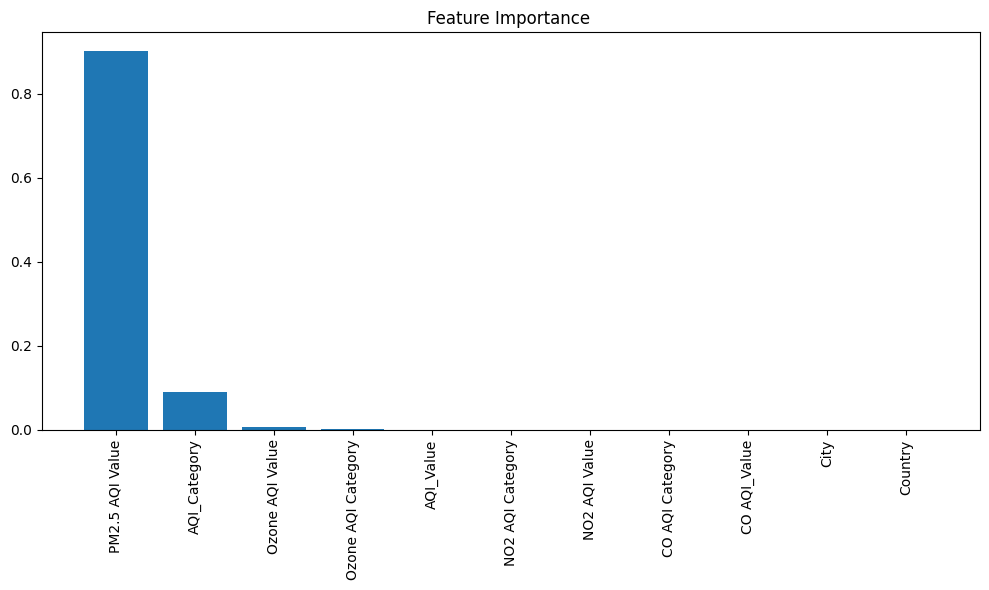

In [ ]:
if hasattr(gbc_model, 'feature_importances_'):
    importances =gbc_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    features = X.columns
plt.figure(figsize=(10, 6))
plt.title("Feature Importance ")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.01
important_features = [features[i] for i in indices if importances[i] > threshold]
print(f"Important features based on threshold {threshold}: {important_features}")


Important features based on threshold 0.01: ['PM2.5 AQI Value', 'AQI_Category']


In [ ]:
threshold = 0.6
important_features = [features[i] for i in indices if importances[i] > threshold]
print(f"Important features based on threshold {threshold}: {important_features}")


Important features based on threshold 0.6: ['PM2.5 AQI Value']


In [ ]:
threshold = 0.006
important_features = [features[i] for i in indices if importances[i] > threshold]
print(f"Important features based on threshold {threshold}: {important_features}")

Important features based on threshold 0.006: ['PM2.5 AQI Value', 'AQI_Category']


In [ ]:
X_train_imp = X_train[important_features]
X_test_imp = X_test[important_features]

In [ ]:
X_train_scaled_imp = scaler.fit_transform(X_train_imp)
X_test_scaled_imp = scaler.transform(X_test_imp)

In [ ]:
svm_model.fit(X_train_scaled_imp, y_train)
svm_pred_imp = svm_model.predict(X_test_scaled_imp)
svm_acc_imp = accuracy_score(y_test, svm_pred_imp)
print(f'SVM Accuracy (with important features): {svm_acc_imp}')

SVM Accuracy (with important features): 0.9963775836352013


In [ ]:
def get_classification_details(y_true, y_pred, X_test):
    correct_classified = X_test[y_true == y_pred]
    incorrect_classified = X_test[y_true != y_pred]
    correct_count = len(correct_classified)
    incorrect_count = len(incorrect_classified)
    print(f'Correctly classified features: {correct_count}')
    print(f'Incorrectly classified features: {incorrect_count}')
    return correct_classified, incorrect_classified

In [ ]:
correct_svm, incorrect_svm = get_classification_details(y_test, svm_pred, X_test)


Correctly classified features: 4666
Incorrectly classified features: 27


In [ ]:
correct_ffnn, incorrect_ffnn = get_classification_details(y_test, ffnn_pred, X_test)

Correctly classified features: 4670
Incorrectly classified features: 23


In [ ]:
correct_xgb, incorrect_xgb = get_classification_details(y_test_encoded, GBC_pred, X_test)

Correctly classified features: 4657
Incorrectly classified features: 36


In [ ]:
correct_ensemble, incorrect_ensemble = get_classification_details(y_test_encoded, ensemble_pred, X_test)

Correctly classified features: 4657
Incorrectly classified features: 36
